# Simple Actor-Critic (QAC) Method from scratch
- QAC (Q-Actor-Critic) refers to a specific variant of the actor-critic framework where the Critic uses the Action-Value function $Q(S, A)$  rather than the State-Value Function $V(s)$ to evaluate the action taken by the actor.

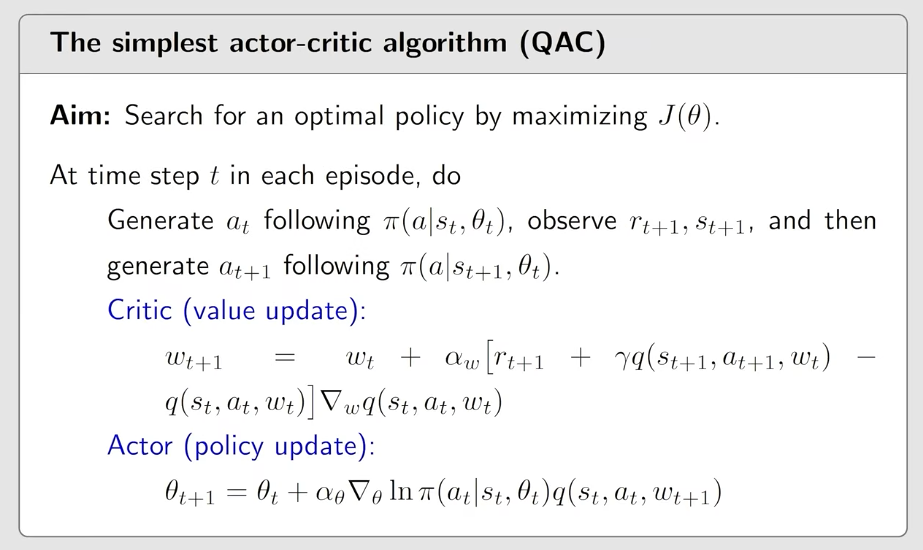

In [9]:
import random
import math
from collections import deque

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [10]:
def random_choice(values, probs):
    r = random.random()
    cumulative = 0.0
    for i in range(len(probs)):
        p = probs[i]
        cumulative += p
        if r <= cumulative:
            return values[i], probs[i]
    return values[-1], probs[-1]  # fallback for floating point edge case

def softmax(z):
    # Subtracting the max value prevents overflow in the exp function
    shift_z = z - np.max(z)
    exp_z = np.exp(shift_z)
    return exp_z / np.sum(exp_z)
    

def soft_policy(theta, state_feat_vec, env):    
    state_feat_vec = np.array(state_feat_vec).reshape(-1, 1)  # state_dim X 1

    # --- linear combination --------
    action_logits = (state_feat_vec.T @ theta).squeeze(0)
    action_probs = softmax(action_logits)
    # print(action_probs)
    # ------------------------------
    action, action_prob = random_choice(env.all_action_idx,
                                        action_probs)
    return action, action_probs

def get_policy_table(theta, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int8)

    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = np.array(state_feat_vec).reshape(-1, 1)  # state_dim X 1
        # X^T * theta
        action_probs = (state_feat_vec.T @ theta).squeeze(0) # n_action_dim
        action, action_prob = random_choice(env.all_action_idx, action_probs)
        policy[state.idx] = np.argmax(action_probs).item()
    return policy

In [11]:
def get_approx_Qsa(W, state, action, env):
    phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
            
    Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
    return Q_s_a


def get_Q_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int16)
    for s in states:
        for a in env.all_action_idx:
            Q[s.idx][a] = get_approx_Qsa(W, s, a, env)
    return Q

## Training step

In [12]:
def compute_score_function_gradient(state_feat_vec, action_probs, action_idx):
    # 1. Ensure state_feat_vec is a column vector (d x 1)
    x = np.array(state_feat_vec).reshape(-1, 1) 
    
    # 2. Create a one-hot vector for the action taken (n x 1)
    e_k = np.zeros_like(action_probs).reshape(-1, 1)
    e_k[action_idx] = 1.0
    
    # 3. Reshape action_probs to a column vector (n x 1)
    pi = np.array(action_probs).reshape(-1, 1)
    
    # 4. Compute the error (n x 1)
    # This tells us how much to "push" each action's weights
    error = e_k - pi
    
    # 5. Compute the Outer Product (d x 1) @ (1 x n) -> (d x n)
    # This result has the same shape as your weight matrix 'theta'
    gradient = x @ error.T
    
    return gradient

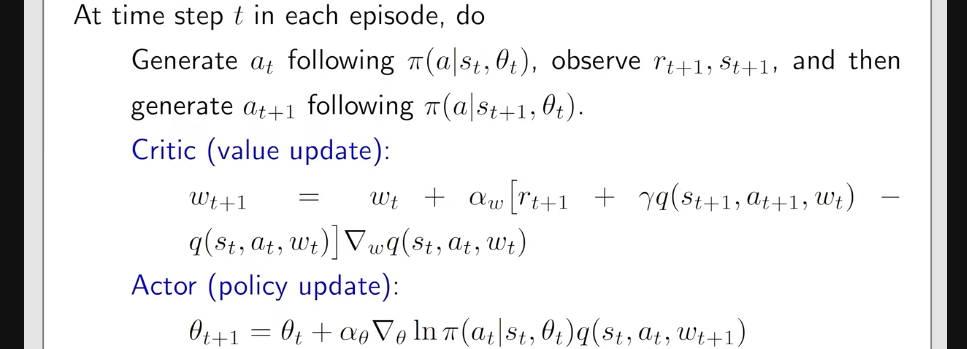

In [390]:
def run_episode(env, W, theta, state, episode_idx, max_step=1000, gamma=0.99, alpha_w=0.01, alpha_t=0.01):
    step = 0
    trajectory = []
    
    # -------- get initial state ---------------
    state_feature_vec = state.get_state_feature_vec(env.n_states) 

    # a_t
    action, action_probs = soft_policy(theta,
                                      state_feature_vec,
                                      env)
    for _ in range(max_step):
        trajectory.append(state.coord)
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        
        next_state_feature_vec = next_state.get_state_feature_vec(env.n_states)    
        # a_t+1
        next_action, next_action_probs = soft_policy(theta,
                                                    next_state_feature_vec,
                                                    env)

        # ======= value update ======================
        next_q_sa = get_approx_Qsa(W, next_state, next_action, env)
        q_sa =  get_approx_Qsa(W, state, action, env)
        
        td_error = reward + gamma * next_q_sa*(1 - int(is_terminated)) - q_sa

        encoded_s_a = state.get_one_hot_encoding(action,
                                                 env.n_states,
                                                 env.n_actions) # state-action feature vector

        W += alpha_w * td_error * encoded_s_a
        
        # ======= policy update =====================
        q_sa =  get_approx_Qsa(W, state, action, env) # w_t+1

        state_feat_vec = state.get_state_feature_vec(env.n_states)
        theta = theta + alpha_t * compute_score_function_gradient(state_feat_vec, action_probs, action) * q_sa
        # ==============================================
        
        state = next_state
        action = next_action
        action_probs = next_action_probs
        state_feature_vec = next_state_feature_vec

        if is_terminated:
            break

    # print("q loss: ", value_loss.item(), "p loss: ", loss.item())
    # trajectory.append(state.coord)
    return theta, W, trajectory

In [445]:
def run_QAC(env, n_episodes=500, gamma=0.8):
    
    policy_histories = []
    Q_histories = []
    trajectory_histories = []
    
    # -------- learning parameter-----------
    theta =  np.random.uniform(size=(env.n_states, env.n_actions))
    W = np.random.uniform(size=(env.n_states * env.n_actions))
    # --------------------------------------
    for episode_idx in range(n_episodes):
        # --- initial state action pair -----
        state = env.find('S')
        # -----------------------------------

        theta, W, trajectory = run_episode(env,
                                           W,
                                           theta,
                                           state,
                                           episode_idx,
                                           gamma=gamma)

        trajectory_histories.append(trajectory)

        if episode_idx % 500 == 0:
            policy = get_policy_table(theta, env)
            Q_table = get_Q_table(W, env)
            policy_histories.append(policy)
            Q_histories.append(Q_table)

    return policy_histories, Q_histories, trajectory_histories

In [460]:
lake_grid = [["G", "F", "F", "F"],
             ["F", "H", "H", "F"],
             ["F", "F", "F", "F"],
             ["H", "F", "S", "F"]]

# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 100,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [461]:
policy_histories, q_histories, trajectory_histories = run_QAC(frozen_lake, n_episodes=15000)

In [462]:
policy = policy_histories[-1]
q_table = q_histories[-1]

In [463]:
policy

array([0, 0, 0, 0, 3, 3, 0, 3, 3, 0, 2, 3, 1, 2, 2, 3], dtype=int8)

In [464]:
# q_table

# Render policy

In [465]:
import pandas as pd
from IPython.display import display

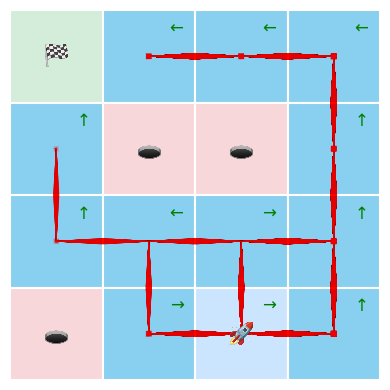

In [466]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)